<a href="https://colab.research.google.com/github/kywch/BubbleView_jsPsych/blob/master/process_todoenglish_petquiz_log.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Todo English petquiz data extraction

Using colab

In [ ]:
!pip install pyathena > /dev/null

# upgrade sqlite3
# https://stackoverflow.com/a/59429952/6729010 
!gdown --id 1BSHIKQ7rFw5BpTq5nw1UZfjPK_7Mpnbi
!mv _sqlite3.cpython-37m-x86_64-linux-gnu.so /usr/lib/python3.7/lib-dynload/
import os
os._exit(00)

ERROR: requests 2.23.0 has requirement urllib3!=1.25.0,!=1.25.1,<1.26,>=1.21.1, but you'll have urllib3 1.26.4 which is incompatible.
ERROR: datascience 0.10.6 has requirement folium==0.2.1, but you'll have folium 0.8.3 which is incompatible.
Downloading...
From: https://drive.google.com/uc?id=1BSHIKQ7rFw5BpTq5nw1UZfjPK_7Mpnbi
To: /content/_sqlite3.cpython-37m-x86_64-linux-gnu.so
6.23MB [00:00, 98.3MB/s]


In [1]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client.
# This only needs to be done once per notebook.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# download the file
import json
key_file = drive.CreateFile({'id': '1cA-QjgQmMN8DmmvWiExlHhzDJZlVPmRa'})
aws_access = json.loads(key_file.GetContentString())

# create athena connection
from pyathena import connect
athena = connect(
    aws_access_key_id = aws_access['aws_access_key_id'],
    aws_secret_access_key = aws_access['aws_secret_access_key'],
    s3_staging_dir = 's3://enuma-dw/',
    region_name = 'us-west-2')

/usr/local/lib/python3.7/dist-packages/requests/__init__.py:91: RequestsDependencyWarning: urllib3 (1.26.4) or chardet (3.0.4) doesn't match a supported version!
  RequestsDependencyWarning)


# Import necessary libraries

In [31]:
#this clears everything loaded in RAM, including the libraries
%reset -f

In [32]:
import pandas as pd
import sqlite3 

import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="white", color_codes=True)
%matplotlib inline

import gc 
from datetime import datetime, timedelta
import json

import numba
from tqdm import tqdm

from google.colab import data_table, files

In [33]:
# mount the google drive
from google.colab import data_table, files, drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# Retrieve all of the petquiz logs


In [3]:
query = """
  SELECT 
    COUNT(1)
  FROM dw.tb_fact_todoenglish_log
  WHERE server_yyyymmdd > '2020-03-01'
    AND v_contentid = 'petquiz'
    AND CARDINALITY(v_useranswer) > 0
"""

%time tmp_df = pd.read_sql(query, athena)
tmp_df


CPU times: user 319 ms, sys: 38.9 ms, total: 358 ms
Wall time: 23 s


,_col0
0,981162


In [6]:
query = """
  SELECT 
    accountid
    , userid
    , sessionid
    , regdate
    , v_source
    , v_contentid
    , v_gamelevel
    , status
    , v_durationtime
    , v_worksheetno
    , v_useranswer
    , v_curriculum_level
    , v_curriculum_day
    , userinfo_regdate
    , deviceinfo_localecountry AS country
  FROM dw.tb_fact_todoenglish_log
  WHERE server_yyyymmdd > '2020-03-01'
    AND v_contentid = 'petquiz'
"""

%time quiz_df = pd.read_sql(query, athena)
quiz_df.to_csv('/content/gdrive/MyDrive/ongoing/todo_english/dw_dump/TE_petquiz_210429.csv.gz', index=False)
files.download('/content/gdrive/MyDrive/ongoing/todo_english/dw_dump/TE_petquiz_210429.csv.gz')

quiz_df

CPU times: user 6min 25s, sys: 14.2 s, total: 6min 39s
Wall time: 21min 53s


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,accountid,userid,sessionid,regdate,v_source,v_contentid,v_gamelevel,status,v_durationtime,v_worksheetno,v_useranswer,v_curriculum_level,v_curriculum_day,userinfo_regdate,country
0,3dc2fc00-6b4b-11eb-8a78-25924de38958,cde95930-6abc-11eb-a0bc-61197dc0a4c8,2021-04-08 02:28:13,2021-04-08 03:39:51,daily,petquiz,UnitTest_9_2,enter,0,0,[],9,206,2021-02-09 09:54:30,KR
1,2bae7b90-3b5b-11eb-afc2-478174c88732,f0ad3070-9354-11eb-bf9f-35e59fbf2dd8,2021-04-08 03:10:46,2021-04-08 03:25:01,daily,petquiz,UnitTest_1_2,abort,27,1,[1#F:1#A],1,206,2021-04-02 01:44:18,KR
2,3dc2fc00-6b4b-11eb-8a78-25924de38958,cde95930-6abc-11eb-a0bc-61197dc0a4c8,2021-04-08 02:28:13,2021-04-08 03:39:40,daily,petquiz,UnitTest_9_2,,0,0,[],0,0,2021-02-09 09:54:30,KR
3,kakao_aa64cb30-5f8a-11eb-9a6d-d5d0afc664a2,5102a4c0-5f8c-11eb-9a6d-d5d0afc664a2,2021-04-08 03:49:32,2021-04-08 03:50:47,None,petquiz,UnitTest_1_7,,0,0,[],0,0,2021-01-26 04:09:42,KR
4,kakao_aa64cb30-5f8a-11eb-9a6d-d5d0afc664a2,5102a4c0-5f8c-11eb-9a6d-d5d0afc664a2,2021-04-08 03:49:32,2021-04-08 03:53:18,daily,petquiz,UnitTest_1_7,enter,0,0,[],1,10306,2021-01-26 04:09:42,KR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3259109,4d7c9c80-5dd9-11ea-a1b6-e91e147c990c,32438ea0-6f4b-11ea-88c7-35f4640e4892,2020-04-10 11:47:04,2020-04-10 12:12:04,None,petquiz,LevelTest_1,,0,0,[],0,0,NaT,None
3259110,4d7c9c80-5dd9-11ea-a1b6-e91e147c990c,32438ea0-6f4b-11ea-88c7-35f4640e4892,2020-04-10 11:47:04,2020-04-10 12:12:12,None,petquiz,LevelTest_1,,0,0,[],0,0,NaT,None
3259111,4d7c9c80-5dd9-11ea-a1b6-e91e147c990c,32438ea0-6f4b-11ea-88c7-35f4640e4892,2020-04-10 11:47:04,2020-04-10 12:12:22,None,petquiz,LevelTest_1,,0,0,[],0,0,NaT,None
3259112,4d7c9c80-5dd9-11ea-a1b6-e91e147c990c,32438ea0-6f4b-11ea-88c7-35f4640e4892,2020-04-10 11:47:04,2020-04-10 12:12:26,None,petquiz,LevelTest_1,,0,0,[],0,0,NaT,None


In [7]:
quiz_df = pd.read_csv('/content/gdrive/MyDrive/ongoing/todo_english/dw_dump/TE_petquiz_210429.csv.gz')

In [8]:
quiz_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3259114 entries, 0 to 3259113
Data columns (total 15 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   accountid           object
 1   userid              object
 2   sessionid           object
 3   regdate             object
 4   v_source            object
 5   v_contentid         object
 6   v_gamelevel         object
 7   status              object
 8   v_durationtime      int64 
 9   v_worksheetno       int64 
 10  v_useranswer        object
 11  v_curriculum_level  int64 
 12  v_curriculum_day    int64 
 13  userinfo_regdate    object
 14  country             object
dtypes: int64(4), object(11)
memory usage: 373.0+ MB


# Cleaning and inspecting `quiz_result`


In [9]:
#quiz_df['regdate'].head()
sum(quiz_df['userinfo_regdate'].isna())

580015

In [10]:
valid_idx = (quiz_df['v_useranswer'] != '[]') & (quiz_df['v_source'] == 'daily') & (quiz_df['regdate'] > '2020-04-01' )

quiz_results = quiz_df[valid_idx]
quiz_results.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 975966 entries, 1 to 3259113
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   accountid           975966 non-null  object
 1   userid              975966 non-null  object
 2   sessionid           975966 non-null  object
 3   regdate             975966 non-null  object
 4   v_source            975966 non-null  object
 5   v_contentid         975966 non-null  object
 6   v_gamelevel         975966 non-null  object
 7   status              975966 non-null  object
 8   v_durationtime      975966 non-null  int64 
 9   v_worksheetno       975966 non-null  int64 
 10  v_useranswer        975966 non-null  object
 11  v_curriculum_level  975966 non-null  int64 
 12  v_curriculum_day    975966 non-null  int64 
 13  userinfo_regdate    804065 non-null  object
 14  country             803108 non-null  object
dtypes: int64(4), object(11)
memory usage: 119.1+ MB


In [11]:
quiz_results['studentid'] = 'acct^' + quiz_results['accountid'] + '^user^' + quiz_results['userid']
#quiz_results['regdate'].head(10)
quiz_results['studentid']

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


1          acct^2bae7b90-3b5b-11eb-afc2-478174c88732^user...
10         acct^kakao_aa64cb30-5f8a-11eb-9a6d-d5d0afc664a...
14         acct^google_111123364994093374486^user^619d1d1...
16         acct^google_108730771957821081983^user^66446d7...
18         acct^google_117202833900898139945^user^468152c...
                                 ...                        
3259095    acct^kakao_1298513223^user^8debd1f0-73d2-11ea-...
3259097    acct^kakao_1251557097^user^312861e0-7341-11ea-...
3259099    acct^kakao_9402fe00-709a-11ea-9e06-f934381cc5e...
3259104    acct^kakao_2d3ef5b0-7320-11ea-b4cd-65dfe99db80...
3259113    acct^4d7c9c80-5dd9-11ea-a1b6-e91e147c990c^user...
Name: studentid, Length: 975966, dtype: object

In [12]:
# also use sqlite3
import sqlite3
conn = sqlite3.connect(":memory:")
%time quiz_results.to_sql('quiz', conn, index=False, if_exists='replace')

CPU times: user 6.61 s, sys: 182 ms, total: 6.79 s
Wall time: 6.8 s


In [13]:
query = """
  SELECT
    v_useranswer
  FROM quiz
  WHERE v_gamelevel = 'UnitTest_13_2'
    AND sessionid > '2021-02-01'
  LIMIT 10
"""

%time tmp_df = pd.read_sql(query, conn)
tmp_df

CPU times: user 6.63 ms, sys: 0 ns, total: 6.63 ms
Wall time: 8.49 ms


,v_useranswer
0,"[1#think_388x320.png:1#think_388x320.png, 2#ta..."
1,"[1#think_388x320.png:1#think_388x320.png, 2#ta..."
2,"[1#think_388x320.png:1#think_388x320.png, 2#ta..."
3,"[1#think_388x320.png:1#think_388x320.png, 2#ta..."
4,"[1#think_388x320.png:1#think_388x320.png, 2#ta..."
5,"[1#think_388x320.png:1#think_388x320.png, 2#ta..."
6,"[1#think_388x320.png:1#think_388x320.png, 2#ta..."
7,"[1#think_388x320.png:1#think_388x320.png, 2#ta..."
8,"[1#think_388x320.png:1#think_388x320.png, 2#ta..."
9,"[1#think_388x320.png:1#think_388x320.png, 2#ta..."


In [14]:
tmp_df.v_useranswer.iloc[0]

"[1#think_388x320.png:1#think_388x320.png, 2#talk_388x320.png:2#talk_388x320.png, 3#know_388x320.png:3#know_388x320.png, 4#grass_388x320.png:4#grass_388x320.png, 5#money:5#money, 5#give:5#give, 5#go:5#go, 6#touches:6#touches, 7#YouIHe:7#areamis, 8#I'm:8#I'm, 9#He's:9#He's, 9#He is:9#He is, 10#goes:10#go]"

In [15]:
query = """
  SELECT
    accountid
    , MAX(userinfo_regdate) AS userinfo_regdate
    , MAX(country) AS country
    , MAX(regdate) AS last_regdate
    , SUM(CASE WHEN status='finish' THEN 1 ELSE 0 END) AS test_cnt  
  FROM quiz
  GROUP BY 1
  ORDER BY 5 DESC
"""

%time tmp_df = pd.read_sql(query, conn)
tmp_df

CPU times: user 2.01 s, sys: 12.8 ms, total: 2.03 s
Wall time: 2.04 s


,accountid,userinfo_regdate,country,last_regdate,test_cnt
0,18d8aa80-ebfc-11ea-b1d3-9912cdbbedb9,2020-09-26 13:06:19,KR,2021-04-27 11:30:04,817
1,fbe9e330-733d-11ea-b4cd-65dfe99db80a,2020-11-27 13:18:57,KR,2021-04-21 02:49:36,607
2,kakao_8a044e20-f8d2-11ea-86d9-f992822eacb9,2020-12-10 07:38:17,KR,2021-04-29 06:08:57,468
3,98bd0b10-d17b-11ea-bf53-07cf77642cfd,2020-12-24 07:53:07,KR,2021-04-27 09:12:48,450
4,74f9eac0-c296-11ea-a047-f74450e3f1cc,2020-07-10 13:37:57,KR,2021-04-26 13:09:08,448
...,...,...,...,...,...
58485,07720940-d616-11ea-b974-23ac0b615754,2021-03-25 12:58:45,CN,2021-03-27 06:39:53,0
58486,0569b090-d52c-11e8-96c8-1dbb7e5304dd,2020-12-31 12:56:59,CN,2020-12-31 23:34:22,0
58487,029d0510-7a62-11ea-9949-235082a5a66e,None,None,2020-04-11 04:28:26,0
58488,0269cca0-5d5a-11eb-b6d9-bdd98fae91b9,2021-01-23 09:05:02,CN,2021-03-30 09:34:56,0


In [ ]:
tmp_df.to_csv('users.csv', index=False)

In [ ]:
#sum(tmp_df[tmp_df['country'].isna()].test_cnt)
sum(tmp_df['userinfo_regdate'].isna())
sum(tmp_df['country'].isna())


12923

**Users who have NULL userinfo_regdate OR country**: 12,923 OUT OF 53,938 accountids
* userinfo_regdate는 있지만 country가 없는 경우: 24 accountids --> 4명은 최근에도 계속 사용?
* userinfo_regdate, country 둘 다 없는 경우는 모두 마지막 테스트 날짜가 2020-07-11 이전임. 
  * Churn된 사용자 이므로 나중에 ELO training data로만 쓸 것.

*이 정보들을 back-fill 할 필요는 없을 듯*




In [16]:
query = """
  SELECT
    accountid
    , userid
    , sessionid
    , regdate
    , v_contentid
    , v_gamelevel
    , status
    , userinfo_regdate
    , country
  FROM quiz
  ORDER BY 1, 2, 3, 4
"""

%time tmp_df2 = pd.read_sql(query, conn)
tmp_df2

CPU times: user 6.28 s, sys: 589 ms, total: 6.87 s
Wall time: 6.88 s


,accountid,userid,sessionid,regdate,v_contentid,v_gamelevel,status,userinfo_regdate,country
0,00030dc0-95ed-11eb-91b8-9bc1a5afa09e,25157390-95ee-11eb-91c6-0bf13aed50ec,2021-04-14 10:52:49,2021-04-14 11:16:05,petquiz,UnitTest_6_1,finish,2021-04-05 09:06:02,KR
1,0004a560-386c-11eb-b814-67d5fe3fb73a,16fe7390-386c-11eb-b814-67d5fe3fb73a,2020-12-09 06:39:35,2020-12-09 07:14:23,petquiz,UnitTest_6_1,finish,2020-12-07 09:10:45,KR
2,0004a560-386c-11eb-b814-67d5fe3fb73a,16fe7390-386c-11eb-b814-67d5fe3fb73a,2020-12-14 13:14:50,2020-12-14 13:16:54,petquiz,UnitTest_6_2,finish,2020-12-07 09:10:45,KR
3,0004a560-386c-11eb-b814-67d5fe3fb73a,16fe7390-386c-11eb-b814-67d5fe3fb73a,2020-12-16 07:14:19,2020-12-16 07:42:43,petquiz,UnitTest_6_3,finish,2020-12-07 09:10:45,KR
4,00070600-b9de-11ea-ae95-45e0b95791cf,8b7b8df0-b9de-11ea-8c9c-3b9e85718287,2020-07-03 11:51:48,2020-07-03 12:02:07,petquiz,UnitTest_3_1,finish,None,None
...,...,...,...,...,...,...,...,...,...
975961,kakao_fffe9b20-9118-11ea-86f4-83fece7d98e8,69fe8800-9119-11ea-bee4-ff57fba94d8a,2020-05-10 03:19:06,2020-05-10 03:33:59,petquiz,UnitTest_1_1,finish,None,None
975962,kakao_fffe9b20-9118-11ea-86f4-83fece7d98e8,69fe8800-9119-11ea-bee4-ff57fba94d8a,2020-05-23 09:24:44,2020-05-23 09:49:53,petquiz,UnitTest_1_2,finish,None,None
975963,kakao_fffe9b20-9118-11ea-86f4-83fece7d98e8,69fe8800-9119-11ea-bee4-ff57fba94d8a,2020-05-25 11:28:56,2020-05-25 11:39:13,petquiz,UnitTest_1_1,finish,None,None
975964,kakao_fffe9b20-9118-11ea-86f4-83fece7d98e8,69fe8800-9119-11ea-bee4-ff57fba94d8a,2020-05-31 02:20:38,2020-05-31 02:40:06,petquiz,UnitTest_1_2,finish,None,None


In [ ]:
tmp_df2.to_csv('check.csv', index=False)

# Unpack `v_useranswer` into Problem-Solving (psolve) data

In [17]:
codes = quiz_results['v_gamelevel'].unique()
print(codes)

def make_numbers_2digits(input):
  if input.isnumeric():
    return input.zfill(2)
  else:
    return input

'_'.join([make_numbers_2digits(input) for input in codes[15].split('_')])

['UnitTest_1_2' 'UnitTest_1_7' 'UnitTest_17_3' 'UnitTest_7_1'
 'UnitTest_1_1' 'UnitTest_3_3' 'UnitTest_9_3' 'UnitTest_2_0'
 'UnitTest_4_1' 'UnitTest_7_3' 'UnitTest_8_1' 'UnitTest_14_4'
 'UnitTest_3_4' 'UnitTest_6_4' 'UnitTest_9_2' 'UnitTest_3_2'
 'UnitTest_6_3' 'UnitTest_1_3' 'UnitTest_3_0' 'LevelTest_7' 'LevelTest_9'
 'UnitTest_11_1' 'UnitTest_4_2' 'UnitTest_9_1' 'UnitTest_3_1'
 'UnitTest_5_2' 'UnitTest_6_2' 'UnitTest_4_3' 'LevelTest_2' 'UnitTest_6_0'
 'LevelTest_4' 'LevelTest_3' 'UnitTest_5_1' 'UnitTest_3_6' 'UnitTest_9_4'
 'LevelTest_5' 'UnitTest_2_2' 'UnitTest_2_1' 'LevelTest_6' 'LevelTest_1'
 'UnitTest_6_1' 'UnitTest_4_0' 'UnitTest_4_4' 'UnitTest_2_3'
 'UnitTest_9_5' 'UnitTest_14_0' 'UnitTest_7_2' 'UnitTest_11_2'
 'UnitTest_6_7' 'UnitTest_10_3' 'UnitTest_5_3' 'UnitTest_10_1'
 'UnitTest_1_4' 'UnitTest_7_5' 'UnitTest_12_1' 'UnitTest_12_3'
 'UnitTest_8_3' 'UnitTest_8_2' 'UnitTest_5_4' 'UnitTest_11_3'
 'UnitTest_6_6' 'LevelTest_11' 'UnitTest_7_0' 'UnitTest_3_5'
 'UnitTest_5_5' 'UnitTe

'UnitTest_03_02'

In [23]:
# get rid of string bits that are defined in ch
@numba.njit
def clean_str(input):
  # remove these characters
  for ch in ['[', ']', '.mp3', '_phonic']:
    if ch in input:
      input = input.replace(ch, '') 
  
  # replace space with underbar
  input = input.replace(' ', '_') 

  # replace comma with dash
  input = input.replace(',', '-') 

  return input.strip()

test = quiz_results['v_useranswer'][10]
#test = tmp_df['v_useranswer'].iloc[0]
#[clean_str(xx).split(':')[0] for xx in test.split(', ')]
[clean_str(xx) for xx in test.split(', ')]

['1#G:1#G',
 '1#E:1#E',
 '2#a:2#a',
 '2#l:2#l',
 '3#d:3#d',
 '4#H:4#H',
 '5#F:5#F',
 '6#j:6#i']

In [22]:
#quiz_results['v_useranswer']

1                                                  [1#F:1#A]
10         [1#G:1#G, 1#E:1#E, 2#a:2#a, 2#l:2#l, 3#d:3#d, ...
14         [1#helicopter_388x320.png:1#helicopter_388x320...
16                     [1#ck:1#ck, 2#nd:2#nd, 3#sing:3#sand]
18         [1#A:1#B, 1#C:1#B, 2#d:2#z, 2#b:2#z, 3#a:3#d, ...
                                 ...                        
3259095    [1#Q:1#Q, 1#S:1#X, 2#t:2#o, 2#r:2#r, 3#s:3#s, ...
3259097    [1#n:1#n, 2#e:2#e, 3#sit:3#sit, 3#net:3#net, 4...
3259099    [1#W:1#C, 1#V:1#Y, 2#u:2#o, 2#w:2#w, 3#u:3#w, ...
3259104    [1#G:1#G, 1#K:1#K, 1#A:1#A, 2#b:2#b, 2#p:2#p, ...
3259113    [1#G:1#E, 1#K:1#K, 1#A:1#A, 2#b:2#b, 2#p:2#e, ...
Name: v_useranswer, Length: 975966, dtype: object

In [24]:
#answer_list.split(', ')
#answer_list
#[clean_str(xx).split(':') for xx in answer_list.split(', ')]
xxx = [clean_str(xx).split(':')[0].split('#') for xx in test.split(', ')]
item_head = xxx[0]
'#'.join([make_numbers_2digits(item_head[0]), item_head[1]])

'01#G'

In [25]:
# let's try value_counts

proc_data = quiz_results #.head()

solve_data = []

for student, country, user_regdate, user_level, session_dt, status, level, answer_list in tqdm(zip(
    proc_data['studentid'],
    proc_data['country'],
    proc_data['userinfo_regdate'],
    proc_data['v_curriculum_level'],
    proc_data['regdate'],
    proc_data['status'],
    proc_data['v_gamelevel'], 
    proc_data['v_useranswer'])
):
  level = '_'.join([make_numbers_2digits(input) for input in level.split('_')])
  for tmp_str in answer_list.split(', '):
    item = clean_str(tmp_str).split(':')
    item_head = item[0].split('#')

    solve_data.append([
      student,
      country,
      user_regdate,
      user_level,
      session_dt,
      status,
      level,
      level + '_' + '#'.join([make_numbers_2digits(item_head[0]), item_head[1]]), # problem id
      item_head[1], # correct answer
      item[1].split('#')[1], # user response
      (item[0] == item[1]) # correct?
    ])


975966it [01:51, 8716.67it/s]


In [26]:
len(solve_data)
#solve_data
#item
#tmp_str
#answer_list
#session_dt


9228670

In [27]:
col_names = ['user_id', 'country', 'user_regdate', 'user_level', 
             'test_dt', 'status', 'test_id', 
             'problem_id', 'corr_answer', 'user_response', 'is_correct']
%time psolve_df = pd.DataFrame(solve_data, columns=col_names)

CPU times: user 10.4 s, sys: 1.2 s, total: 11.6 s
Wall time: 11.6 s


In [28]:
psolve_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9228670 entries, 0 to 9228669
Data columns (total 11 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   user_id        object
 1   country        object
 2   user_regdate   object
 3   user_level     int64 
 4   test_dt        object
 5   status         object
 6   test_id        object
 7   problem_id     object
 8   corr_answer    object
 9   user_response  object
 10  is_correct     bool  
dtypes: bool(1), int64(1), object(9)
memory usage: 712.9+ MB


In [29]:
psolve_df.to_csv('/content/gdrive/MyDrive/ongoing/todo_english/psolve_210429.csv.gz', index=False)
#files.download('/content/gdrive/MyDrive/ongoing/todo_english/psolve.csv.gz')

# Check `psolve` data

In [ ]:
# mount the google drive and copy files
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [30]:
# clear the memory
query = """
  DROP TABLE quiz
"""
conn.cursor().execute(query)

import gc 
del quiz_results
gc.collect()

482

In [37]:
# also use sqlite3
import sqlite3
conn = sqlite3.connect(":memory:")

In [34]:
psolve_df = pd.read_csv('/content/gdrive/MyDrive/ongoing/todo_english/psolve_210429.csv.gz')

In [38]:
psolve_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9228670 entries, 0 to 9228669
Data columns (total 11 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   user_id        object
 1   country        object
 2   user_regdate   object
 3   user_level     int64 
 4   test_dt        object
 5   status         object
 6   test_id        object
 7   problem_id     object
 8   corr_answer    object
 9   user_response  object
 10  is_correct     bool  
dtypes: bool(1), int64(1), object(9)
memory usage: 712.9+ MB


In [39]:
%time psolve_df.to_sql('psolve', conn, index=False, if_exists='replace')

CPU times: user 42.9 s, sys: 808 ms, total: 43.8 s
Wall time: 43.8 s


**Some checks to do**
* abort vs. finish accuracy
* participants split-half (earlier vs. current cohorts)

## Check 1: abort vs finish item-level accuracy

* Accuracy in the aborted sessions are lower than that in the finished session (from the paired t-test).
* Yet, these are highly correlated (r=.86)

* The pattern seems to be that the accuracy of later items in each test tends to be much lower. 


In [40]:
# check 1: abort vs. finish accuracy?

query = """
  WITH finish AS
  (
    SELECT
      problem_id
      , COUNT(1) AS try_cnt
      , SUM(is_correct) AS corr_cnt
      , CAST(SUM(is_correct) AS FLOAT) / COUNT(1) AS acc_fin
      , 100 * SUM(is_correct) / COUNT(1) AS acc_fin_pcnt
      , MAX(test_id) AS test_id
    FROM psolve
    WHERE status = 'finish'
    GROUP BY 1
    ORDER BY 1
  ), 

  abort AS
  (
    SELECT
      problem_id
      , COUNT(1) AS try_cnt
      , SUM(is_correct) AS corr_cnt
      , CAST(SUM(is_correct) AS FLOAT) / COUNT(1) AS acc_abt
      , 100 * SUM(is_correct) / COUNT(1) AS acc_abt_pcnt
    FROM psolve
    WHERE status = 'abort'
    GROUP BY 1
    ORDER BY 1
  ), 

  by_user AS
  (
    SELECT
      problem_id
      , COUNT(DISTINCT user_id) AS user_cnt
      , SUM(CASE WHEN wrong_cnt == 0 THEN 1 ELSE 0 END) AS corr_only
    FROM (
      SELECT
        problem_id
        , user_id
        , COUNT(1) AS try_cnt
        , SUM(is_correct) AS corr_cnt
        , SUM(1 - is_correct) AS wrong_cnt
      FROM psolve
      GROUP BY 1, 2
    )
    GROUP BY 1
  )

  SELECT
    f.test_id
    , f.problem_id
    , f.try_cnt AS try_fin
    , f.acc_fin
    , f.acc_fin_pcnt
    , a.try_cnt AS try_abt
    , a.acc_abt
    , a.acc_abt_pcnt
    , b.user_cnt
    , CAST(b.corr_only AS FLOAT)/b.user_cnt AS prop_corr_only_user
    , 100 * b.corr_only / b.user_cnt AS pcnt_corr_only_user
  FROM finish f
    LEFT JOIN abort a ON f.problem_id = a.problem_id
    LEFT JOIN by_user b ON f.problem_id = b.problem_id
"""

%time check1_df = pd.read_sql(query, conn)
check1_df

CPU times: user 1min 4s, sys: 532 ms, total: 1min 5s
Wall time: 1min 4s


,test_id,problem_id,try_fin,acc_fin,acc_fin_pcnt,try_abt,acc_abt,acc_abt_pcnt,user_cnt,prop_corr_only_user,pcnt_corr_only_user
0,LevelTest_01,LevelTest_01_01#A,32313,0.917216,91,9806.0,0.933306,93.0,23425,0.878463,87
1,LevelTest_01,LevelTest_01_01#G,32313,0.779810,77,13098.0,0.802107,80.0,23481,0.664197,66
2,LevelTest_01,LevelTest_01_01#K,32313,0.826262,82,11124.0,0.828928,82.0,23440,0.736817,73
3,LevelTest_01,LevelTest_01_02#b,32313,0.847089,84,9241.0,0.855968,85.0,23412,0.778746,77
4,LevelTest_01,LevelTest_01_02#n,32313,0.544827,54,5762.0,0.415828,41.0,23367,0.390636,39
...,...,...,...,...,...,...,...,...,...,...,...
1867,UnitTest_17_07,UnitTest_17_07_06#Don't,1,1.000000,100,NaN,NaN,NaN,1,1.000000,100
1868,UnitTest_17_07,UnitTest_17_07_07#not,1,1.000000,100,NaN,NaN,NaN,1,1.000000,100
1869,UnitTest_17_07,UnitTest_17_07_08#watch-not_watch,1,1.000000,100,NaN,NaN,NaN,1,1.000000,100
1870,UnitTest_17_07,UnitTest_17_07_09#motorcycle_388x320.png,1,1.000000,100,NaN,NaN,NaN,1,1.000000,100


In [41]:
check1_df.to_csv('/content/gdrive/MyDrive/ongoing/todo_english/TE_petquiz_problems.csv', index=False)
files.download('/content/gdrive/MyDrive/ongoing/todo_english/TE_petquiz_problems.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
valid_idx = (check1_df['user_cnt'] > 19)
sum(valid_idx)

1663

In [43]:
# correlation
check1_df[valid_idx][['acc_fin', 'acc_abt', 'prop_corr_only_user']].corr()

,acc_fin,acc_abt,prop_corr_only_user
acc_fin,1.000000,0.819035,0.991825
acc_abt,0.819035,1.000000,0.833962
prop_corr_only_user,0.991825,0.833962,1.000000


In [44]:
# paired t-test
print(stats.ttest_rel(check1_df[valid_idx].acc_fin, check1_df[valid_idx].acc_abt))
print('acc_fin: ', np.mean(check1_df[valid_idx].acc_fin), np.std(check1_df[valid_idx].acc_fin))
print('acc_abt: ', np.mean(check1_df[valid_idx].acc_abt), np.std(check1_df[valid_idx].acc_abt))
print('prop_corr_only_user: ', np.mean(check1_df[valid_idx].prop_corr_only_user), np.std(check1_df[valid_idx].prop_corr_only_user))

Ttest_relResult(statistic=nan, pvalue=nan)
acc_fin:  0.7789783106588701 0.29087527064526814
acc_abt:  0.640024124335066 0.3306613797581827
prop_corr_only_user:  0.7455577842071226 0.2892564369009573


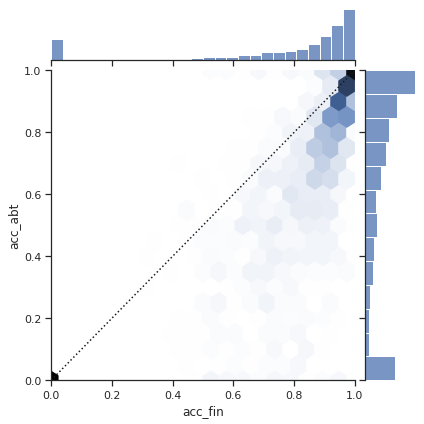

In [45]:
sns.set_style('ticks', {'xtick.direction': 'out', 'ytick.direction':'out'})

p = sns.jointplot(data=check1_df[valid_idx], x='acc_fin', y='acc_abt', 
                  kind="hex", xlim=(0, 1), ylim=(0,1))
plt.plot([0, 1], [0, 1], 'k:')


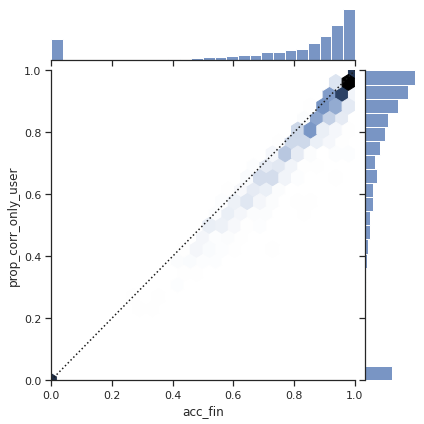

In [46]:
sns.set_style('ticks', {'xtick.direction': 'out', 'ytick.direction':'out'})

p = sns.jointplot(data=check1_df[valid_idx], x='acc_fin', y='prop_corr_only_user', 
                  kind="hex", xlim=(0, 1), ylim=(0,1))
plt.plot([0, 1], [0, 1], 'k:')


In [ ]:
valid_idx = (check1_df.prop_corr_only_user > .95)
check1_df[valid_idx].to_csv('test.csv', index=False)

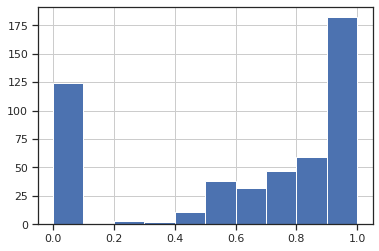

In [ ]:
valid_idx = (check1_df['user_cnt'] < 100)
check1_df[valid_idx]['prop_corr_only_user'].hist()

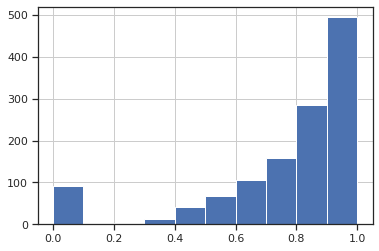

In [ ]:
valid_idx = (check1_df['user_cnt'] > 100)
check1_df[valid_idx]['prop_corr_only_user'].hist()

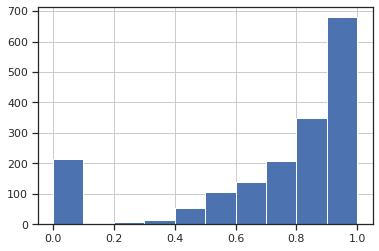

In [ ]:
check1_df['prop_corr_only_user'].hist()

In [47]:
# check 1: abort vs. finish accuracy?

query = """
  WITH user_prob AS
  (
    SELECT
      problem_id
      , user_id
      , COUNT(1) AS try_cnt
      , SUM(is_correct) AS corr_cnt
      , SUM(1 - is_correct) AS wrong_cnt
    FROM psolve
    GROUP BY 1, 2
  ), 

  by_user AS
  (
    SELECT
      problem_id
      , COUNT(DISTINCT user_id) AS user_cnt
      , SUM(CASE WHEN wrong_cnt == 0 THEN 1 ELSE 0 END) AS corr_only
    FROM user_prob
    GROUP BY 1
  ), 

  by_user2 AS
  (
    SELECT
      problem_id
      , COUNT(DISTINCT user_id) AS user_cnt
      , SUM(CASE WHEN wrong_cnt == 0 THEN 1 ELSE 0 END) AS corr_only
    FROM user_prob
    WHERE try_cnt > 1
    GROUP BY 1
  ) 

  SELECT 
    b.problem_id
    , b.user_cnt
    , CAST(b.corr_only AS FLOAT) / b.user_cnt AS acc1
    , c.user_cnt AS user_cnt2
    , CAST(c.corr_only AS FLOAT) / c.user_cnt AS acc2
  FROM by_user b
    LEFT JOIN by_user2 c ON b.problem_id = c.problem_id
"""

%time tmp_df = pd.read_sql(query, conn)


CPU times: user 1min 26s, sys: 510 ms, total: 1min 26s
Wall time: 1min 26s


In [48]:
tmp_df

,problem_id,user_cnt,acc1,user_cnt2,acc2
0,LevelTest_01_01#A,23425,0.878463,6000.0,0.824667
1,LevelTest_01_01#G,23481,0.664197,6532.0,0.583588
2,LevelTest_01_01#K,23440,0.736817,6202.0,0.644147
3,LevelTest_01_02#b,23412,0.778746,5871.0,0.703287
4,LevelTest_01_02#n,23367,0.390636,5162.0,0.254746
...,...,...,...,...,...
1867,UnitTest_17_07_06#Don't,1,1.000000,NaN,NaN
1868,UnitTest_17_07_07#not,1,1.000000,NaN,NaN
1869,UnitTest_17_07_08#watch-not_watch,1,1.000000,NaN,NaN
1870,UnitTest_17_07_09#motorcycle_388x320.png,1,1.000000,NaN,NaN


In [49]:
valid_idx = (tmp_df['user_cnt2'] > 30)
#tmp_df[valid_idx]['acc2'].hist()
#print(sum(valid_idx))

print('acc_fin: ', np.mean(tmp_df[valid_idx].acc2), np.std(tmp_df[valid_idx].acc2))


acc_fin:  0.6562889753715866 0.2637716486176958


In [50]:
valid_idx = (tmp_df['try_cnt'] > 4)
tmp_df[valid_idx].sample(20)

KeyError: ignored

## Check 2: earlier vs. current cohorts

Based on the churned month, define
* Current cohort: ~29000 users whose last month is 2021-02 and 2021-03
* Earlier cohort: ~39000 users whose last month is earlier than 2021-02

Current vs. earlier cohorts
* The accuracies are almost identical (r=.994).
* Paired t-test yields a statitically significant difference but it's too small to be meaningful (with 1000 problems).
  * acc_curr: 81.7% +- 24.1% (Mean, SD)
  * acc_early: 81.4% +- 24.3%


In [ ]:
# account counts by chured month?
query = """
  WITH acct AS
  (
    SELECT
      user_id
      , SUBSTR(MAX(test_dt), 0,8) AS last_month
    FROM psolve
    GROUP BY 1
  )

  SELECT 
    last_month
    , COUNT(1) AS churned_cnt
  FROM acct
  GROUP BY 1
"""

%time tmp_df = pd.read_sql(query, conn)
tmp_df['churned_sum'] = tmp_df.cumsum()['churned_cnt']
tmp_df

CPU times: user 14 s, sys: 221 ms, total: 14.3 s
Wall time: 14.3 s


,last_month,churned_cnt,churned_sum
0,2020-04,4373,4373
1,2020-05,5304,9677
2,2020-06,4491,14168
3,2020-07,2774,16942
4,2020-08,2510,19452
5,2020-09,3219,22671
6,2020-10,2476,25147
7,2020-11,2603,27750
8,2020-12,3782,31532
9,2021-01,7463,38995


In [ ]:
# account counts by chured month?
query = """
  WITH last_month AS
  (
    SELECT
      user_id
      , SUBSTR(MAX(test_dt), 0,8) AS last_month
    FROM psolve
    GROUP BY 1
  ), 

  early AS
  (
    SELECT
      problem_id
      , COUNT(1) AS try_cnt
      , SUM(is_correct) AS corr_cnt
      , CAST(SUM(is_correct) AS FLOAT) / COUNT(1) AS acc_fin
    FROM psolve p
      INNER JOIN last_month lm ON p.user_id = lm.user_id
    WHERE p.status = 'finish'
      AND lm.last_month < '2021-02'     
    GROUP BY 1
    ORDER BY 1
  ), 

  current AS
  (
    SELECT
      problem_id
      , COUNT(1) AS try_cnt
      , SUM(is_correct) AS corr_cnt
      , CAST(SUM(is_correct) AS FLOAT) / COUNT(1) AS acc_fin
    FROM psolve p
      INNER JOIN last_month lm ON p.user_id = lm.user_id
    WHERE p.status = 'finish'
      AND lm.last_month >= '2021-02'     
    GROUP BY 1
    ORDER BY 1
  ) 

  SELECT
    c.problem_id
    , c.try_cnt AS try_curr
    , c.acc_fin AS acc_curr
    , e.try_cnt AS try_early
    , e.acc_fin AS acc_early
  FROM current c
  LEFT JOIN early e ON c.problem_id = e.problem_id
"""

%time check2_df = pd.read_sql(query, conn)
check2_df


CPU times: user 51.6 s, sys: 394 ms, total: 52 s
Wall time: 52.1 s


,problem_id,try_curr,acc_curr,try_early,acc_early
0,LevelTest_01_01#A,18400,0.917337,10452.0,0.917145
1,LevelTest_01_01#G,18400,0.781793,10452.0,0.769900
2,LevelTest_01_01#K,18400,0.826957,10452.0,0.821183
3,LevelTest_01_02#b,18400,0.845707,10452.0,0.847111
4,LevelTest_01_02#n,18400,0.552065,10452.0,0.517604
...,...,...,...,...,...
1765,UnitTest_17_03_06#Don't,6,1.000000,NaN,NaN
1766,UnitTest_17_03_07#not,6,0.833333,NaN,NaN
1767,UnitTest_17_03_08#watch-not_watch,6,1.000000,NaN,NaN
1768,UnitTest_17_03_09#motorcycle_388x320.png,6,1.000000,NaN,NaN


In [ ]:
valid_idx = (check2_df['try_curr'] > 29) & (check2_df['try_early'] > 29)
sum(valid_idx)

1059

In [ ]:
# correlation
check2_df[valid_idx][['acc_curr', 'acc_early']].corr()

,acc_curr,acc_early
acc_curr,1.00000,0.99383
acc_early,0.99383,1.00000


In [ ]:
# paired t-test
print(stats.ttest_rel(check2_df[valid_idx].acc_curr, check2_df[valid_idx].acc_early))
print('acc_curr: ', np.mean(check2_df[valid_idx].acc_curr), np.std(check2_df[valid_idx].acc_curr))
print('acc_early: ', np.mean(check2_df[valid_idx].acc_early), np.std(check2_df[valid_idx].acc_early))

Ttest_relResult(statistic=3.4340175206182937, pvalue=0.000617753180662154)
acc_curr:  0.8166943041079199 0.2407764763375253
acc_early:  0.8138425713522107 0.24334500342515253


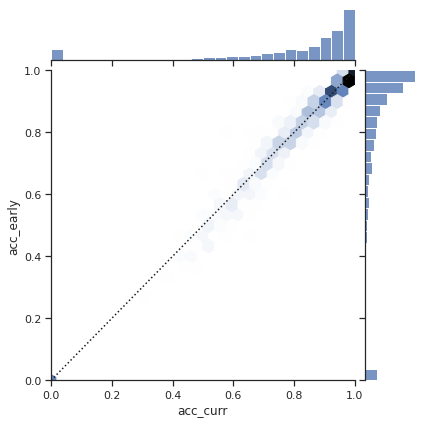

In [ ]:
sns.set_style('ticks', {'xtick.direction': 'out', 'ytick.direction':'out'})

p = sns.jointplot(data=check2_df[valid_idx], x='acc_curr', y='acc_early', 
                  kind="hex", xlim=(0, 1), ylim=(0,1))
plt.plot([0, 1], [0, 1], 'k:')

# Aggregate the data

## Individual test session-level data

In [51]:
# check whether the same user takes the same quiz multiple times
# this excludes aborts ... so count is likely underestimated

query = """
  SELECT 
    test_id
    , COUNT(DISTINCT test_dt) AS test_cnt
    , COUNT(DISTINCT user_id) AS user_cnt
  FROM psolve
  WHERE status = 'finish'
    AND test_dt > '2021-01-01'
  GROUP BY 1
"""

%time tmp_df = pd.read_sql(query, conn)
#tmp_df.to_csv('check3.csv', index=False)
#files.download('check3.csv')
tmp_df

CPU times: user 10 s, sys: 146 ms, total: 10.1 s
Wall time: 10.1 s


,test_id,test_cnt,user_cnt
0,LevelTest_01,15429,11162
1,LevelTest_02,9411,7451
2,LevelTest_03,8080,6674
3,LevelTest_04,5120,4515
4,LevelTest_05,3869,3454
...,...,...,...
140,UnitTest_17_00,1,1
141,UnitTest_17_01,95,81
142,UnitTest_17_02,74,65
143,UnitTest_17_03,45,39


In [52]:
# individual quiz-taking data
query = """
  WITH user AS
  (
    SELECT
      user_id
      , SUM(CASE WHEN status = 'finish' THEN 1 ELSE 0 END) AS fin_cnt
      , SUM(CASE WHEN status = 'abort' THEN 1 ELSE 0 END) AS abt_cnt
    FROM (
      SELECT DISTINCT
        user_id
        , test_dt
        , status
      FROM psolve
      WHERE test_dt > '2021-01-01'
    )
    GROUP BY 1
  )

  SELECT 
    p.user_id
    , u.fin_cnt AS test_fin_cnt
    , u.abt_cnt AS test_abt_cnt
    , p.test_dt
    , p.test_id
    , p.status
    , COUNT(1) AS item_cnt
    , SUM(p.is_correct) AS corr_cnt
  FROM psolve p
    LEFT JOIN user u ON p.user_id = u.user_id
  WHERE test_dt > '2021-01-01'
  GROUP BY 1, 2, 3, 4
"""

%time user_test_df = pd.read_sql(query, conn)
user_test_df

CPU times: user 22.6 s, sys: 184 ms, total: 22.8 s
Wall time: 22.7 s


,user_id,test_fin_cnt,test_abt_cnt,test_dt,test_id,status,item_cnt,corr_cnt
0,acct^00030dc0-95ed-11eb-91b8-9bc1a5afa09e^user...,1,0,2021-04-14 11:16:05,UnitTest_06_01,finish,10,8
1,acct^000e9df0-9d29-11eb-a18e-110ef2f87178^user...,1,0,2021-04-28 11:22:54,UnitTest_01_01,finish,10,10
2,acct^00106ac0-5ad2-11eb-8311-2da58f37c67c^user...,20,2,2021-01-22 11:58:29,UnitTest_06_01,finish,10,6
3,acct^00106ac0-5ad2-11eb-8311-2da58f37c67c^user...,20,2,2021-01-25 02:32:06,UnitTest_06_02,finish,10,9
4,acct^00106ac0-5ad2-11eb-8311-2da58f37c67c^user...,20,2,2021-01-27 01:32:18,UnitTest_06_03,finish,10,10
...,...,...,...,...,...,...,...,...
473338,acct^kakao_fffc7ee0-95bc-11eb-9a76-8551072920a...,3,0,2021-04-19 12:16:14,UnitTest_03_01,finish,10,8
473339,acct^kakao_fffc7ee0-95bc-11eb-9a76-8551072920a...,3,0,2021-04-29 10:56:14,UnitTest_03_02,finish,10,9
473340,acct^kakao_fffdbe10-54e7-11eb-9310-07a8d96c777...,3,0,2021-01-19 09:01:05,UnitTest_01_01,finish,10,7
473341,acct^kakao_fffdbe10-54e7-11eb-9310-07a8d96c777...,3,0,2021-02-02 11:20:46,UnitTest_01_02,finish,10,5


In [53]:
user_test_df.to_csv('/content/gdrive/MyDrive/ongoing/todo_english/TE_petquiz_indsess.csv', index=False)
files.download('/content/gdrive/MyDrive/ongoing/todo_english/TE_petquiz_indsess.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Test-level summary data

In [54]:
# Aggregate across test_id
# use only 'finish'ed tests

query = """
  WITH ind_test AS
  (
    SELECT
      user_id
      , test_id
      , test_dt
      , status
      , COUNT(1) AS item_cnt
      , SUM(is_correct) AS corr_cnt
    FROM psolve
    WHERE test_dt > '2021-01-01'
    GROUP BY 1, 2, 3, 4
  ), 

  test_cnt AS
  (
    SELECT
      test_id
      , COUNT(DISTINCT user_id) AS user_cnt
      , SUM(CASE WHEN status='finish' THEN 1 ELSE 0 END) AS fin_cnt
      , SUM(CASE WHEN status='abort' THEN 1 ELSE 0 END) AS abt_cnt
    FROM ind_test
    GROUP BY 1
  ), 

  test_perf AS
  (
    SELECT 
      test_id
      , AVG(item_cnt) AS item_cnt
      , AVG(corr_cnt) AS avg_corr
      , AVG(CAST(corr_cnt AS float)/item_cnt) AS accuracy
    FROM ind_test
    WHERE status = 'finish'
    GROUP BY 1
  )

  SELECT 
    c.test_id
    , c.user_cnt
    , c.fin_cnt AS test_fin_cnt
    , c.abt_cnt AS test_abt_cnt
    , CAST(c.abt_cnt AS FLOAT)/(c.fin_cnt + c.abt_cnt) AS test_abt_rate
    , p.item_cnt
    , p.avg_corr
    , p.accuracy
    , CAST(100 * p.accuracy AS INT) AS acc_pcnt
  FROM test_cnt c
    LEFT JOIN test_perf p ON c.test_id = p.test_id
"""

%time test_summ_df = pd.read_sql(query, conn)
test_summ_df

CPU times: user 20 s, sys: 281 ms, total: 20.3 s
Wall time: 20.4 s


,test_id,user_cnt,test_fin_cnt,test_abt_cnt,test_abt_rate,item_cnt,avg_corr,accuracy,acc_pcnt
0,LevelTest_01,11301,15451,6004,0.279842,16.059025,13.109961,0.816414,81
1,LevelTest_02,7528,9418,6269,0.399630,16.054364,12.847207,0.800999,80
2,LevelTest_03,6716,8085,3386,0.295179,15.042672,12.598639,0.837650,83
3,LevelTest_04,4532,5121,1754,0.255127,15.038079,13.274360,0.882549,88
4,LevelTest_05,3494,3871,1546,0.285398,15.035133,13.427021,0.893016,89
...,...,...,...,...,...,...,...,...,...
140,UnitTest_17_00,1,1,0,0.000000,12.000000,8.000000,0.666667,66
141,UnitTest_17_01,81,95,40,0.296296,12.126316,10.442105,0.860526,86
142,UnitTest_17_02,65,74,25,0.252525,12.000000,11.337838,0.944820,94
143,UnitTest_17_03,39,45,22,0.328358,13.000000,12.688889,0.976068,97


In [55]:
test_summ_df.to_csv('/content/gdrive/MyDrive/ongoing/todo_english/TE_petquiz_summary.csv', index=False)
files.download('/content/gdrive/MyDrive/ongoing/todo_english/TE_petquiz_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Wrong-answer database

In [56]:
query = """
  WITH prob AS
  (
    SELECT
      problem_id
      , COUNT(1) AS try_cnt
      , COUNT(DISTINCT user_response) AS option_num
    FROM psolve
    GROUP BY 1
  ), 

  user_resp AS
  (
    SELECT
      problem_id
      , user_response
      , COUNT(1) AS resp_cnt
    FROM psolve
    GROUP BY 1, 2
  )

  SELECT
    u.problem_id
    , p.try_cnt
    , p.option_num
    , u.user_response
    , u.resp_cnt  
  FROM user_resp u
    LEFT JOIN prob p ON u.problem_id = p.problem_id
  ORDER BY 1, 5 DESC
"""

%time user_resp_df = pd.read_sql(query, conn)
user_resp_df

CPU times: user 39.4 s, sys: 194 ms, total: 39.6 s
Wall time: 39.6 s


,problem_id,try_cnt,option_num,user_response,resp_cnt
0,LevelTest_01_01#A,42119,26,A,38790
1,LevelTest_01_01#A,42119,26,K,400
2,LevelTest_01_01#A,42119,26,B,328
3,LevelTest_01_01#A,42119,26,C,194
4,LevelTest_01_01#A,42119,26,H,188
...,...,...,...,...,...
6196,UnitTest_17_07_06#Don't,1,1,Don't,1
6197,UnitTest_17_07_07#not,1,1,not,1
6198,UnitTest_17_07_08#watch-not_watch,1,1,watch-not_watch,1
6199,UnitTest_17_07_09#motorcycle_388x320.png,1,1,motorcycle_388x320.png,1


In [ ]:
tmp_df.to_csv('/content/gdrive/MyDrive/ongoing/todo_english/TE_petquiz_answers.csv', index=False)
files.download('/content/gdrive/MyDrive/ongoing/todo_english/TE_petquiz_answers.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Revisiting the individual user-session data

Try something like this from Todo Math.

```sql
  WITH user AS
  (
    SELECT
      accountid
      , userid
      , monster
      , COUNT(1) AS try_cnt
      , SUM(CASE WHEN v_totalproblem = v_currentproblem THEN 1 ELSE 0 END) AS finish_cnt
      , SUM(CASE WHEN (v_totalproblem = v_currentproblem) AND (v_solved >= '4') THEN 1 ELSE 0 END) AS pass_cnt
    FROM quiz
    GROUP BY 1, 2, 3
    HAVING monster < 'T'
    ORDER BY 1, 2, 3
  )

  SELECT
    monster
    , COUNT(DISTINCT userid) AS try_user

    , SUM(CASE WHEN pass_cnt > 0 THEN 1 ELSE 0 END) AS pass_user
    , 100*CAST(SUM(CASE WHEN pass_cnt > 0 THEN 1 ELSE 0 END) AS REAL)
      / COUNT(DISTINCT userid) AS pass_user_pcnt

    , SUM(CASE WHEN (try_cnt = 1) AND (finish_cnt = 1) THEN 1 ELSE 0 END) AS one_try_user
    , SUM(CASE WHEN (try_cnt = 1) AND (finish_cnt = 1) AND (pass_cnt = 1) THEN 1 ELSE 0 END) AS one_try_pass_user
    , 100*CAST(SUM(CASE WHEN (try_cnt = 1) AND (finish_cnt = 1) AND (pass_cnt = 1) THEN 1 ELSE 0 END) AS REAL)
      / SUM(CASE WHEN (try_cnt = 1) AND (finish_cnt = 1) THEN 1 ELSE 0 END) AS one_try_pass_pcnt

    , SUM(CASE WHEN finish_cnt = 2 THEN 1 ELSE 0 END) AS two_try_user
    , SUM(CASE WHEN (finish_cnt = 2) AND (pass_cnt = 0) THEN 1 ELSE 0 END) AS two_try_0_pass_user
    , SUM(CASE WHEN (finish_cnt = 2) AND (pass_cnt = 1) THEN 1 ELSE 0 END) AS two_try_1_pass_user
    , SUM(CASE WHEN (finish_cnt = 2) AND (pass_cnt = 2) THEN 1 ELSE 0 END) AS two_try_2_pass_user

    , SUM(CASE WHEN try_cnt > finish_cnt THEN 1 ELSE 0 END) AS abort_user
    , 100*CAST(SUM(CASE WHEN try_cnt > finish_cnt THEN 1 ELSE 0 END) AS REAL)
      / COUNT(DISTINCT userid) AS abort_user_pcnt
  FROM user
  GROUP BY 1
  ORDER BY 1
```

In [66]:
# individual quiz-taking data
query = """
  WITH ind_sess AS
  (
    SELECT
      user_id
      , test_dt
      , test_id
      , MAX(status) AS status
      , COUNT(1) AS item_cnt
      , SUM(is_correct) AS corr_cnt
      , CAST(SUM(is_correct) AS REAL)/COUNT(1) AS score
      , CAST(SUM(is_correct) AS REAL)/COUNT(1) >= .8 AS pass
    FROM psolve
    GROUP BY 1, 2, 3
    ORDER BY 1, 2
  ), 

  user AS
  (
    SELECT
      user_id
      , test_id
      , COUNT(1) AS try_cnt
      , SUM(CASE WHEN status = 'finish' THEN 1 ELSE 0 END) AS finish_cnt
      , SUM(CASE WHEN (status = 'finish') AND (pass = TRUE) THEN 1 ELSE 0 END) AS pass_cnt
    FROM ind_sess
    GROUP BY 1, 2
    ORDER BY 1, 2
  )

  SELECT
    test_id
    , COUNT(DISTINCT user_id) AS try_user
 
    , SUM(CASE WHEN pass_cnt > 0 THEN 1 ELSE 0 END) AS pass_user
    , 100*CAST(SUM(CASE WHEN pass_cnt > 0 THEN 1 ELSE 0 END) AS REAL)
      / COUNT(DISTINCT user_id) AS pass_user_pcnt
 
    , SUM(CASE WHEN (try_cnt = 1) AND (finish_cnt = 1) THEN 1 ELSE 0 END) AS one_try_user
    , SUM(CASE WHEN (try_cnt = 1) AND (finish_cnt = 1) AND (pass_cnt = 1) THEN 1 ELSE 0 END) AS one_try_pass_user
    , 100*CAST(SUM(CASE WHEN (try_cnt = 1) AND (finish_cnt = 1) AND (pass_cnt = 1) THEN 1 ELSE 0 END) AS REAL)
      / SUM(CASE WHEN (try_cnt = 1) AND (finish_cnt = 1) THEN 1 ELSE 0 END) AS one_try_pass_pcnt
 
    , SUM(CASE WHEN finish_cnt = 2 THEN 1 ELSE 0 END) AS two_try_user
    , SUM(CASE WHEN (finish_cnt = 2) AND (pass_cnt = 0) THEN 1 ELSE 0 END) AS two_try_0_pass_user
    , SUM(CASE WHEN (finish_cnt = 2) AND (pass_cnt = 1) THEN 1 ELSE 0 END) AS two_try_1_pass_user
    , SUM(CASE WHEN (finish_cnt = 2) AND (pass_cnt = 2) THEN 1 ELSE 0 END) AS two_try_2_pass_user
 
    , SUM(CASE WHEN try_cnt > finish_cnt THEN 1 ELSE 0 END) AS abort_user
    , 100*CAST(SUM(CASE WHEN try_cnt > finish_cnt THEN 1 ELSE 0 END) AS REAL)
      / COUNT(DISTINCT user_id) AS abort_user_pcnt
  FROM user
  GROUP BY 1
  ORDER BY 1
"""

%time pass_df = pd.read_sql(query, conn)
pass_df

CPU times: user 24.5 s, sys: 271 ms, total: 24.7 s
Wall time: 24.7 s


,test_id,try_user,pass_user,pass_user_pcnt,one_try_user,one_try_pass_user,one_try_pass_pcnt,two_try_user,two_try_0_pass_user,two_try_1_pass_user,two_try_2_pass_user,abort_user,abort_user_pcnt
0,LevelTest_01,23481,14185,60.410545,16871,8799,52.154585,1781,315,622,844,5054,21.523785
1,LevelTest_02,14556,8847,60.779060,9619,4889,50.826489,1182,219,421,542,4113,28.256389
2,LevelTest_03,13214,9594,72.604813,9776,6652,68.044190,1069,118,362,589,2528,19.131224
3,LevelTest_04,8483,7085,83.519981,6388,5192,81.277395,680,32,181,467,1544,18.201108
4,LevelTest_05,6555,5501,83.920671,4715,3896,82.629905,525,22,116,387,1425,21.739130
...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,UnitTest_17_00,1,0,0.000000,1,0,0.000000,0,0,0,0,0,0.000000
141,UnitTest_17_01,81,74,91.358025,52,48,92.307692,9,0,1,8,21,25.925926
142,UnitTest_17_02,65,62,95.384615,41,38,92.682927,9,0,2,7,17,26.153846
143,UnitTest_17_03,39,38,97.435897,23,22,95.652174,3,0,0,3,13,33.333333


In [67]:
pass_df.to_csv('/content/gdrive/MyDrive/ongoing/todo_english/TE_petquiz_pass.csv', index=False)
files.download('/content/gdrive/MyDrive/ongoing/todo_english/TE_petquiz_pass.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from collections import Counter

uniq_ids = Counter(simple_probid).keys() # equals to list(set(words))
count_ps = Counter(simple_probid).values() # counts the elements' frequency

In [57]:
psolve_df.head()

,user_id,country,user_regdate,user_level,test_dt,status,test_id,problem_id,corr_answer,user_response,is_correct
0,acct^2bae7b90-3b5b-11eb-afc2-478174c88732^user...,KR,2021-04-02 01:44:18,1,2021-04-08 03:25:01,abort,UnitTest_01_02,UnitTest_01_02_01#F,F,A,False
1,acct^kakao_aa64cb30-5f8a-11eb-9a6d-d5d0afc664a...,KR,2021-01-26 04:09:42,1,2021-04-08 03:52:52,abort,UnitTest_01_07,UnitTest_01_07_01#G,G,G,True
2,acct^kakao_aa64cb30-5f8a-11eb-9a6d-d5d0afc664a...,KR,2021-01-26 04:09:42,1,2021-04-08 03:52:52,abort,UnitTest_01_07,UnitTest_01_07_01#E,E,E,True
3,acct^kakao_aa64cb30-5f8a-11eb-9a6d-d5d0afc664a...,KR,2021-01-26 04:09:42,1,2021-04-08 03:52:52,abort,UnitTest_01_07,UnitTest_01_07_02#a,a,a,True
4,acct^kakao_aa64cb30-5f8a-11eb-9a6d-d5d0afc664a...,KR,2021-01-26 04:09:42,1,2021-04-08 03:52:52,abort,UnitTest_01_07,UnitTest_01_07_02#l,l,l,True
